# Zomato Restaurant EDA - Exploratory Data Analysis
### A Classroom Data Analytics Project - Zomato Dataset
---

You already know how to load data and apply basic Pandas operations. Now we step into the real analyst's workflow - **Exploratory Data Analysis (EDA)**.

Zomato is one of India's largest food delivery and restaurant discovery platforms. In this project we will work through their global restaurant dataset - **9,551 restaurants** across multiple countries — and answer the kind of questions a food-tech business actually needs answered:

- Which cities and cuisines have the highest-rated restaurants?
- What is the relationship between cost, rating, and votes?
- Which price range delivers the best value?
- Does online delivery affect restaurant ratings?
- Where are the outliers and what do they tell us?

### What this notebook covers
1. Introduction to EDA
2. Understanding the Dataset
3. Data Quality Assessment
4. Univariate Analysis
5. Bivariate Analysis
6. Multivariate Analysis
7. Outlier & Missing Value Analysis
8. Feature Relationships & Pattern Discovery
9. Insights & Business Conclusions
10. Complete End-to-End EDA Summary

Let's get started.

---
## Phase 1 - Introduction to Exploratory Data Analysis

**What is EDA?**  
Exploratory Data Analysis (EDA) is the process of **visually and statistically investigating a dataset** before building models or dashboards. It was popularized by statistician John Tukey in the 1970s.

**Why EDA before Machine Learning?**  
- You cannot build a good model on bad or misunderstood data  
- EDA reveals hidden patterns, outliers, and relationships  
- It tells you **which features matter** and which don't  
- It prevents costly mistakes downstream

**The EDA Workflow:**
```
Load Data → Understand Structure → Assess Quality → Univariate → Bivariate → Multivariate → Insights
```

**Questions every analyst asks before starting:**
- How many rows and columns?
- What are the data types?
- Are there missing values or duplicates?
- What does each column represent?
- What business questions can this data answer?

---
## Phase 2 — Setting Up & Loading the Dataset

In [318]:
# Import the libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


**Business Scenario:** The Zomato data team has shared a global restaurant dataset for analysis. Before anything else, we load it and take a first look.

In [319]:
# Load the dataset
df = pd.read_csv("zomato.csv", encoding="latin1")
print("Dataset loaded successfully!")

# Show the first 5 rows
df.head()

Dataset loaded successfully!


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


---
## Phase 2 — Understanding the Dataset

**What we'll do:** Inspect the structure, column names, data types, and basic summary.  
**Why it matters:** You cannot analyze what you do not understand.

In [320]:
# Dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
print("\nColumn Names:")

for column in df.columns:
    print(column)

Rows: 9551
Columns: 21

Column Names:
Restaurant ID
Restaurant Name
Country Code
City
Address
Locality
Locality Verbose
Longitude
Latitude
Cuisines
Average Cost for two
Currency
Has Table booking
Has Online delivery
Is delivering now
Switch to order menu
Price range
Aggregate rating
Rating color
Rating text
Votes


In [321]:
# Data types of each column
df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


In [322]:
# Detailed info — memory usage, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [323]:
# Statistical summary of numerical columns
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [324]:
# Get numerical columns
numerical_cols = df.select_dtypes(include="number").columns

# Get categorical columns
categorical_cols = df.select_dtypes(include="object").columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Restaurant ID', 'Country Code', 'Longitude', 'Latitude',
       'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes'],
      dtype='object')

Categorical Columns:
Index(['Restaurant Name', 'City', 'Address', 'Locality', 'Locality Verbose',
       'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery',
       'Is delivering now', 'Switch to order menu', 'Rating color',
       'Rating text'],
      dtype='object')


**Dataset Column Reference:**

| Column | Type | Description |
|--------|------|-------------|
| Restaurant ID | Numerical | Unique ID for each restaurant |
| Restaurant Name | Categorical | Name of the restaurant |
| Country Code | Numerical | Country the restaurant is in |
| City | Categorical | City of the restaurant |
| Cuisines | Categorical | Type of cuisine(s) served |
| Average Cost for two | Numerical | Average cost for 2 people |
| Price range | Numerical | Price category (1=cheap, 4=expensive) |
| Aggregate rating | Numerical | Overall rating (0 to 5) |
| Rating text | Categorical | Text label (Poor/Average/Good/Very Good/Excellent) |
| Votes | Numerical | Number of votes/reviews |

---
## Phase 3 — Data Quality Assessment

**Business Scenario:** Before presenting any analysis to stakeholders, the data must be verified for quality. Garbage in = garbage out.

**What we'll check:** Missing values, duplicates, incorrect types, inconsistent values.

In [325]:
missing_values = df.isnull().sum()
missing_values

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


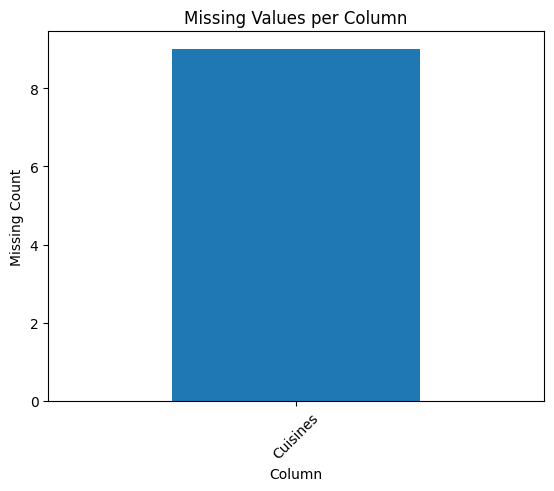

In [326]:
# Visualize missing values

missing_values = missing_values[missing_values > 0]
missing_values.plot(kind="bar")

plt.title("Missing Values per Column")
plt.xlabel("Column")
plt.ylabel("Missing Count")

plt.xticks(rotation=45)
plt.show()

In [327]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [328]:
# Check missing values in the Cuisines column
print("Missing Cuisines:", df["Cuisines"].isnull().sum())

# Fill missing values with "Unknown"
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

print("Missing values filled with Unknown")

Missing Cuisines: 9
Missing values filled with Unknown


In [329]:
# Check for inconsistent values in Yes/No columns
for col in ['Has Table booking', 'Has Online delivery', 'Is delivering now']:
    print(f"{col}: {df[col].unique()}")

Has Table booking: ['Yes' 'No']
Has Online delivery: ['No' 'Yes']
Is delivering now: ['No' 'Yes']


In [330]:
# Calculate data completeness

total_values = df.shape[0] * df.shape[1]
missing_values = df.isnull().sum().sum()

complete_values = total_values - missing_values

completeness = complete_values / total_values * 100

print("Data Completeness:", round(completeness, 2), "%")
print("Dataset is ready for analysis!")

Data Completeness: 100.0 %
Dataset is ready for analysis!


---
## Phase 4 — Univariate Analysis

**Business Scenario:** Study each variable individually to understand its distribution and behavior.  
**What we'll use:** Histograms, Box plots, KDE plots, Value counts, Bar charts.

In [331]:
# Summary statistics
stats = df[
    [
        "Aggregate rating",
        "Votes",
        "Average Cost for two",
        "Price range"
    ]
].describe()

stats

,Aggregate rating,Votes,Average Cost for two,Price range
count,9551.000000,9551.000000,9551.000000,9551.000000
mean,2.666370,156.909748,1199.210763,1.804837
std,1.516378,430.169145,16121.183073,0.905609
min,0.000000,0.000000,0.000000,1.000000
25%,2.500000,5.000000,250.000000,1.000000
50%,3.200000,31.000000,400.000000,2.000000
75%,3.700000,131.000000,700.000000,2.000000
max,4.900000,10934.000000,800000.000000,4.000000


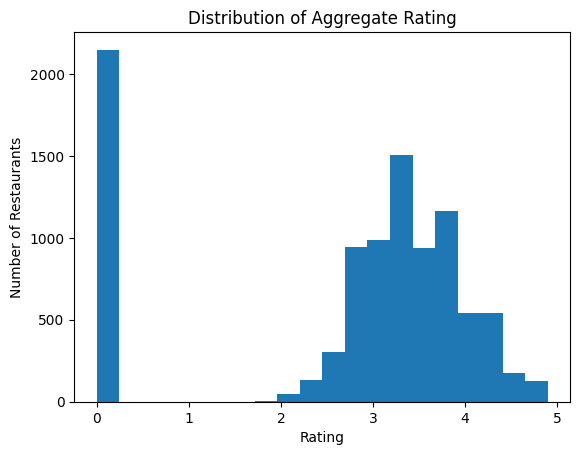

Skewness: -0.954


In [332]:
# Distribution of Aggregate Rating

# Create a histogram
plt.hist(df["Aggregate rating"], bins=20)

plt.title("Distribution of Aggregate Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

# Calculate skewness
skewness = df["Aggregate rating"].skew()

print("Skewness:", round(skewness, 3))

In [333]:
# Calculate skewness
skewness = df["Aggregate rating"].skew()

print("Skewness:", round(skewness, 3))

Skewness: -0.954


Rating Text Frequency:
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


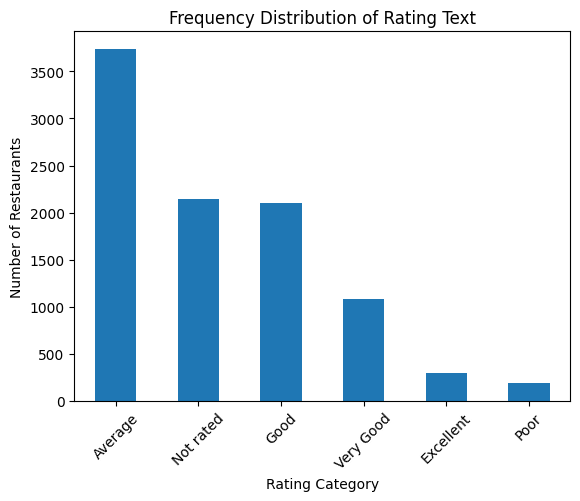

In [334]:
# Count each rating category
rating_counts = df["Rating text"].value_counts()

# Display the counts
print("Rating Text Frequency:")
print(rating_counts)

# Create a bar chart
rating_counts.plot(kind="bar")

plt.title("Frequency Distribution of Rating Text")
plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)
plt.show()

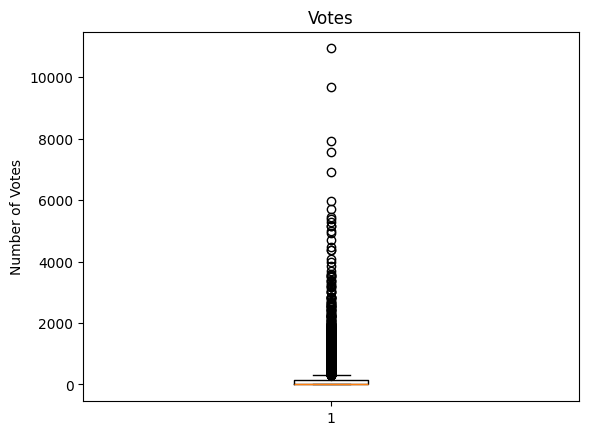

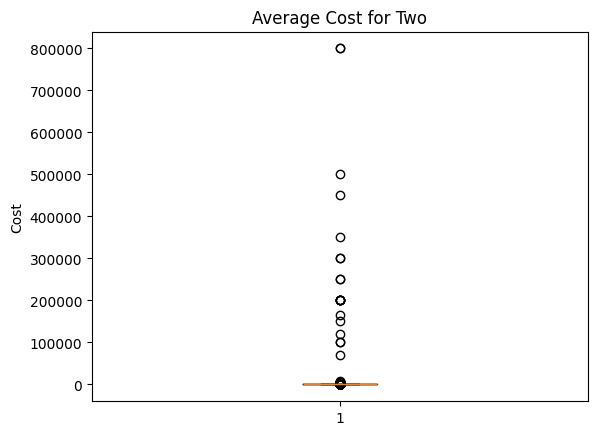

In [335]:
# Box Plot for Votes

plt.boxplot(df["Votes"])

plt.title("Votes")
plt.ylabel("Number of Votes")

plt.show()


# Box Plot for Average Cost for Two

plt.boxplot(df["Average Cost for two"])

plt.title("Average Cost for Two")
plt.ylabel("Cost")

plt.show()

Price Range Distribution:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


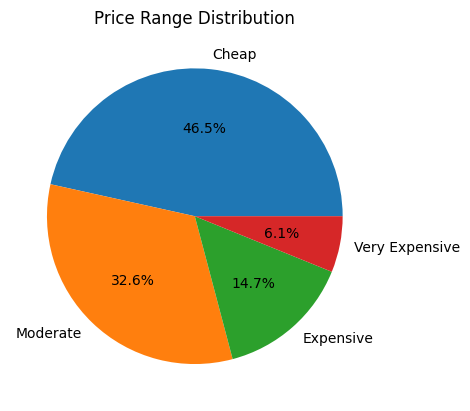

In [336]:
# Price Range Distribution
price_counts = df["Price range"].value_counts().sort_index()
print("Price Range Distribution:")
print(price_counts)

# Create a pie chart
plt.pie(
    price_counts.values,
    labels=["Cheap", "Moderate", "Expensive", "Very Expensive"],
    autopct="%1.1f%%"
)
plt.title("Price Range Distribution")
plt.show()

Top 10 Cities:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


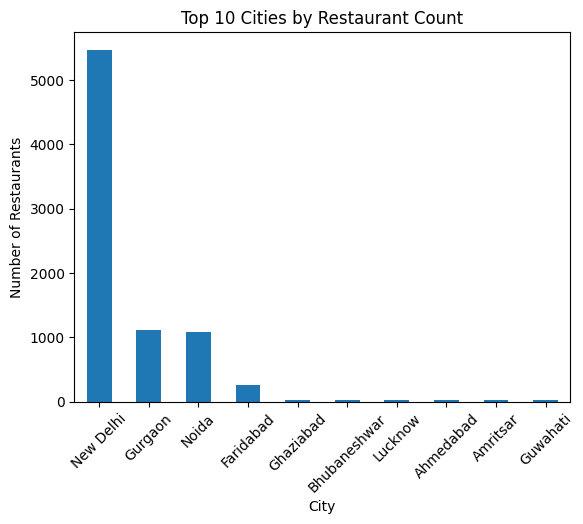

In [337]:
# Top 10 Cities by Restaurant Count

# Count restaurants in each city
top_cities = df["City"].value_counts().head(10)

print("Top 10 Cities:")
print(top_cities)

# Create a bar chart
top_cities.plot(kind="bar")

plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)
plt.show()

---
## Phase 5 — Bivariate Analysis

**Business Scenario:** Explore relationships between two variables.  
**What we'll use:** Scatter plots, Box plots by category, Grouped statistics, Correlation.

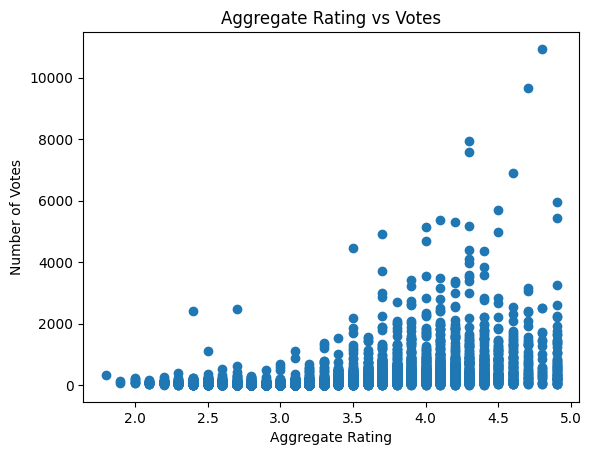

Correlation: 0.409


In [338]:
# Rating vs Votes

# Remove restaurants with a rating of 0
rated = df[df["Aggregate rating"] > 0]

# Create a scatter plot
plt.scatter(
    rated["Aggregate rating"],
    rated["Votes"]
)

plt.title("Aggregate Rating vs Votes")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Votes")

plt.show()

# Calculate correlation
correlation = rated["Aggregate rating"].corr(
    rated["Votes"]
)

print("Correlation:", round(correlation, 3))

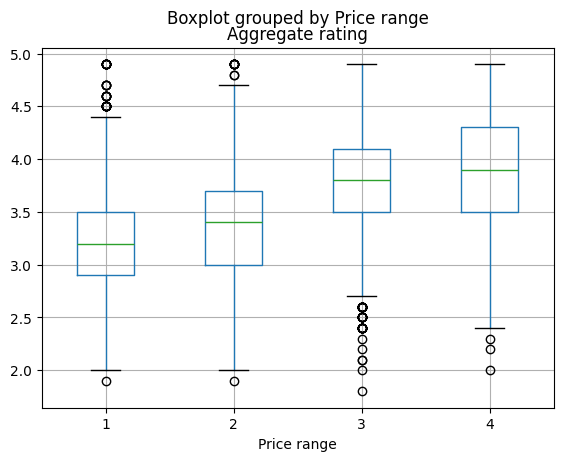

Price range
1    3.238885
2    3.377167
3    3.777276
4    3.890957
Name: Aggregate rating, dtype: float64


In [339]:
# Keep restaurants with a rating
rated = df[df["Aggregate rating"] > 0]

# Compare ratings by price range
rated.boxplot(
    column="Aggregate rating",
    by="Price range"
)
plt.show()

# Show average rating
print(
    rated.groupby("Price range")["Aggregate rating"].mean()
)

Has Online delivery    No   Yes
Has Table booking              
No                   6377  2016
Yes                   723   435


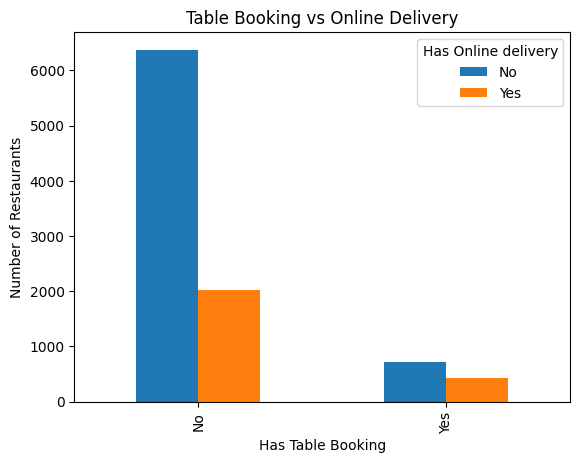

In [340]:
# Table Booking vs Online Delivery

# Create a cross-tabulation
table = pd.crosstab(
    df["Has Table booking"],
    df["Has Online delivery"]
)

# Display the table
print(table)

# Create a bar chart
table.plot(kind="bar")

plt.title("Table Booking vs Online Delivery")
plt.xlabel("Has Table Booking")
plt.ylabel("Number of Restaurants")

plt.show()

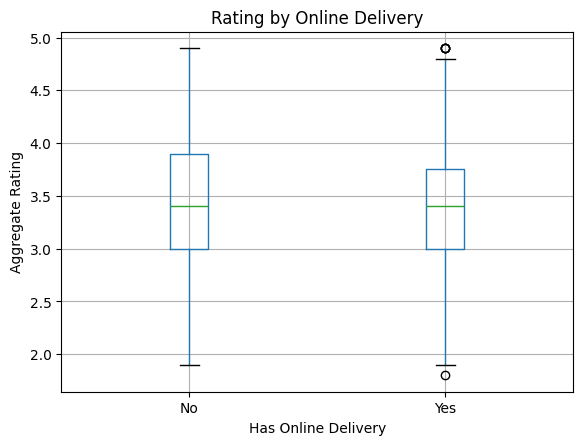

Average Rating by Online Delivery:
Has Online delivery
No     3.467
Yes    3.381
Name: Aggregate rating, dtype: float64


In [341]:
# Keep only restaurants with a rating
rated = df[df["Aggregate rating"] > 0]

# Create a box plot
rated.boxplot(
    column="Aggregate rating",
    by="Has Online delivery"
)

plt.title("Rating by Online Delivery")
plt.suptitle("")
plt.xlabel("Has Online Delivery")
plt.ylabel("Aggregate Rating")

plt.show()

# Calculate average rating
average_rating = (
    rated
    .groupby("Has Online delivery")["Aggregate rating"]
    .mean()
)

print("Average Rating by Online Delivery:")
print(average_rating.round(3))

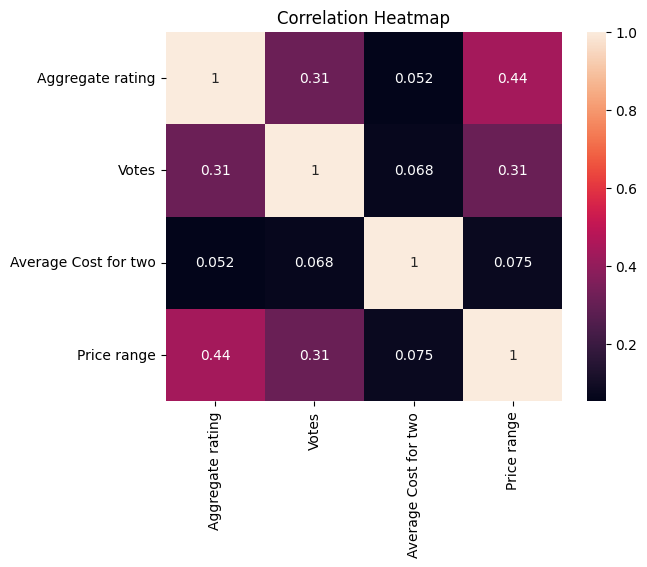

Correlation with Aggregate Rating:
Aggregate rating        1.000000
Price range             0.437944
Votes                   0.313691
Average Cost for two    0.051792
Name: Aggregate rating, dtype: float64


In [342]:
# Select numerical columns

columns = [
    "Aggregate rating",
    "Votes",
    "Average Cost for two",
    "Price range"
]

# Calculate correlation
correlation = df[columns].corr()

# Create a heatmap
sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

# Show correlation with Aggregate Rating
print("Correlation with Aggregate Rating:")
print(
    correlation["Aggregate rating"]
    .sort_values(ascending=False)
)

---
## Phase 6 — Multivariate Analysis

**Business Scenario:** Understand interactions between multiple variables simultaneously.  
**What we'll use:** Pair plots, multi-group comparisons, pivot tables.

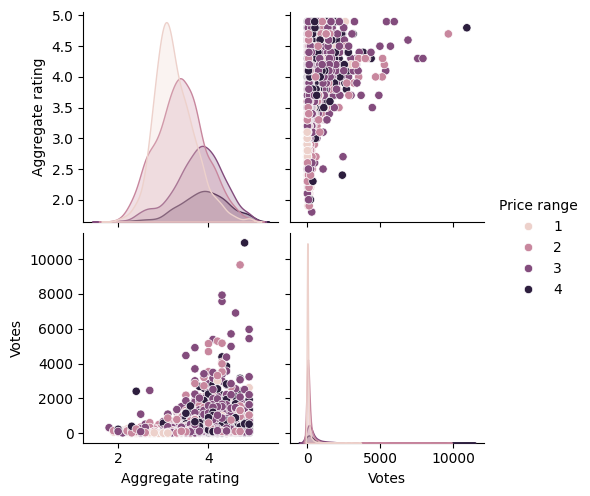

In [343]:
# Pair Plot — All Numerical Variables Colored by Price Range

rated = df[df["Aggregate rating"] > 0]

sns.pairplot(
    rated[
        [
            "Aggregate rating",
            "Votes",
            "Price range"
        ]
    ],
    hue="Price range"
)

plt.show()

In [344]:
# Select the top 8 cities

top_cities = df["City"].value_counts().head(8)

print("Top 8 Cities:")
print(top_cities)

Top 8 Cities:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Name: count, dtype: int64


In [345]:
# Calculate average rating by city and online delivery

average_rating = df[
    df["City"].isin(top_cities.index)
].groupby(
    ["City", "Has Online delivery"]
)["Aggregate rating"].mean()

print(average_rating.round(2))

City          Has Online delivery
Ahmedabad     No                     4.11
              Yes                    4.21
Bhubaneshwar  No                     3.98
Faridabad     No                     1.67
              Yes                    3.07
Ghaziabad     No                     2.61
              Yes                    3.21
Gurgaon       No                     2.26
              Yes                    3.30
Lucknow       No                     4.20
New Delhi     No                     2.14
              Yes                    3.24
Noida         No                     1.58
              Yes                    2.93
Name: Aggregate rating, dtype: float64


In [346]:
# Create a pivot table

pivot = df[
    df["City"].isin(top_cities.index)
].pivot_table(
    values="Aggregate rating",
    index="City",
    columns="Has Online delivery",
    aggfunc="mean"
)

print(pivot.round(2))

Has Online delivery    No   Yes
City                           
Ahmedabad            4.11  4.21
Bhubaneshwar         3.98   NaN
Faridabad            1.67  3.07
Ghaziabad            2.61  3.21
Gurgaon              2.26  3.30
Lucknow              4.20   NaN
New Delhi            2.14  3.24
Noida                1.58  2.93


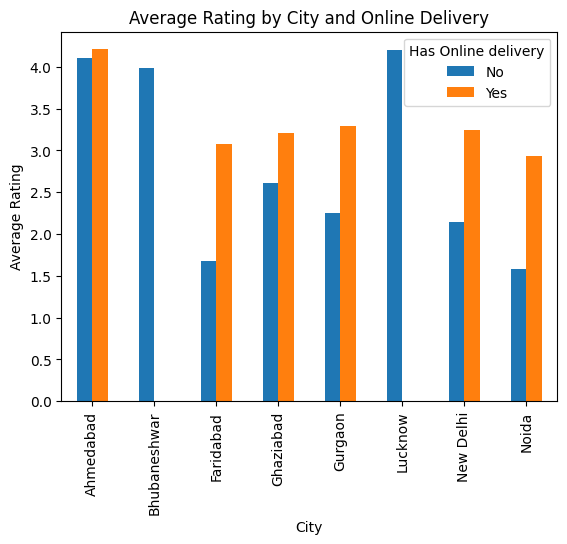

In [347]:
# Create a bar chart

pivot.plot(kind="bar")

plt.title("Average Rating by City and Online Delivery")
plt.xlabel("City")
plt.ylabel("Average Rating")

plt.show()

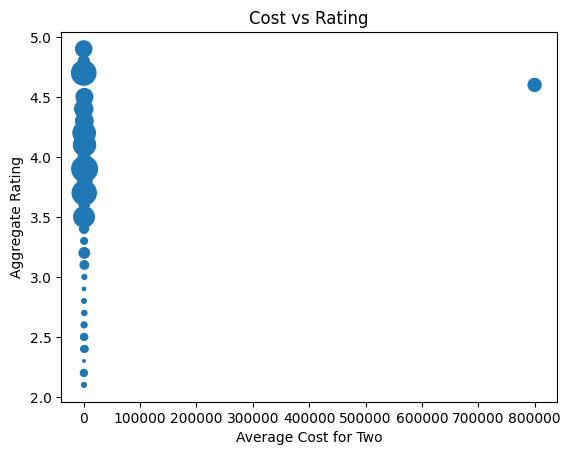

In [348]:
# Select 500 restaurants
sample = rated.sample(500)

# Create a scatter plot
plt.scatter(
    sample["Average Cost for two"],
    sample["Aggregate rating"],
    s=sample["Votes"] / 10
)

plt.title("Cost vs Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")

plt.show()

---
## Phase 7 — Outlier & Missing Value Analysis

**Business Scenario:** Outliers can distort analysis. We need to detect and decide what to do with them.  
**Methods:** IQR Method, Z-Score Method.

In [349]:
# Detect outliers in Votes using the IQR method

# Find Q1 and Q3
Q1 = df["Votes"].quantile(0.25)
Q3 = df["Votes"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate the lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Find outliers
outliers = df[
    (df["Votes"] < lower_limit) |
    (df["Votes"] > upper_limit)
]

# Display the results
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of Outliers:", len(outliers))

Q1: 5.0
Q3: 131.0
IQR: 126.0
Lower Limit: -184.0
Upper Limit: 320.0
Number of Outliers: 1126


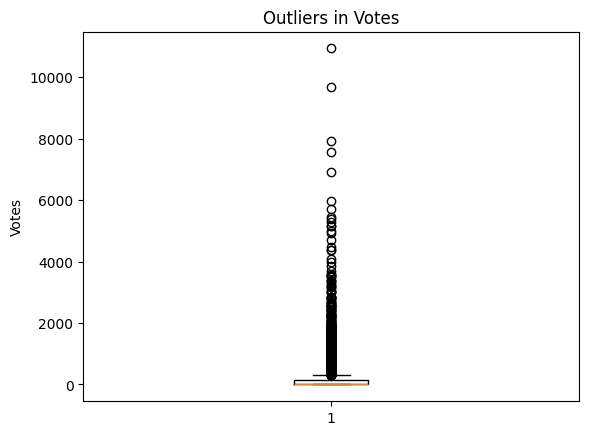

In [350]:
# Box Plot for Votes

plt.boxplot(df["Votes"])

plt.title("Outliers in Votes")
plt.ylabel("Votes")

plt.show()

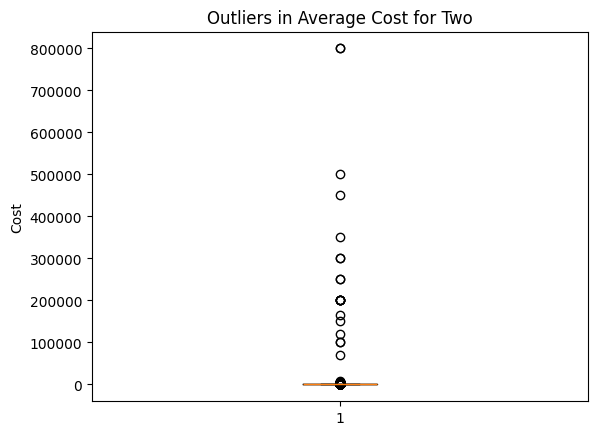

In [351]:
# Box Plot for Average Cost for Two

plt.boxplot(df["Average Cost for two"])

plt.title("Outliers in Average Cost for Two")
plt.ylabel("Cost")

plt.show()

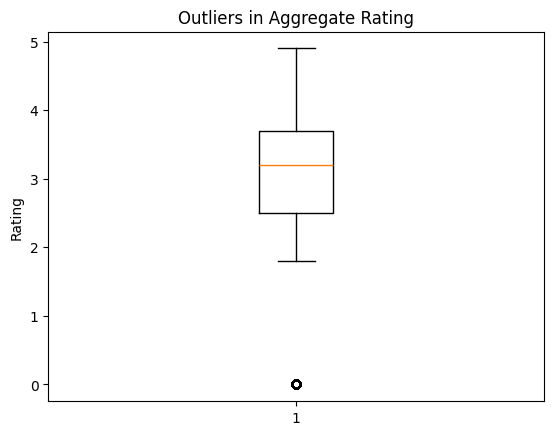

In [352]:
# Box Plot for Aggregate Rating

plt.boxplot(df["Aggregate rating"])

plt.title("Outliers in Aggregate Rating")
plt.ylabel("Rating")

plt.show()

In [353]:
# Z-Score Method

# Calculate the mean and standard deviation
mean = df["Votes"].mean()
std = df["Votes"].std()

# Calculate Z-score
z_score = (df["Votes"] - mean) / std

# Find outliers
outliers = df[abs(z_score) > 3]

print("Number of Outliers:", len(outliers))

# Show the restaurants with the highest votes
print("Top 5 Restaurants by Votes:")

print(
    df.nlargest(
        5,
        "Votes"
    )[
        [
            "Restaurant Name",
            "City",
            "Votes",
            "Aggregate rating"
        ]
    ]
)

Number of Outliers: 173
Top 5 Restaurants by Votes:
                Restaurant Name       City  Votes  Aggregate rating
728                        Toit  Bangalore  10934               4.8
735                    Truffles  Bangalore   9667               4.7
3994           Hauz Khas Social  New Delhi   7931               4.3
2412                  Peter Cat    Kolkata   7574               4.3
739   AB's - Absolute Barbecues  Bangalore   6907               4.6


In [354]:
# When NOT to remove outliers
print("=== When NOT to Remove Outliers ===")
print()
print("In this Zomato dataset:")
print("• Restaurants with 10,000+ votes are REAL — they are famous brands")
print("• Average cost of 800,000 is real — it's a luxury fine-dining restaurant")
print("• Removing these would delete valuable business signals")
print()
print("Rule: Remove outliers only if they are DATA ERRORS, not genuine business anomalies")

=== When NOT to Remove Outliers ===

In this Zomato dataset:
• Restaurants with 10,000+ votes are REAL — they are famous brands
• Average cost of 800,000 is real — it's a luxury fine-dining restaurant
• Removing these would delete valuable business signals

Rule: Remove outliers only if they are DATA ERRORS, not genuine business anomalies


---
## Phase 8 — Feature Relationships & Pattern Discovery

**Business Scenario:** Discover trends, meaningful relationships, and hidden patterns in the data.

/tmp/ipykernel_1973/1060338112.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_rating['mean'], y=cuisine_rating.index, palette='RdYlGn_r')


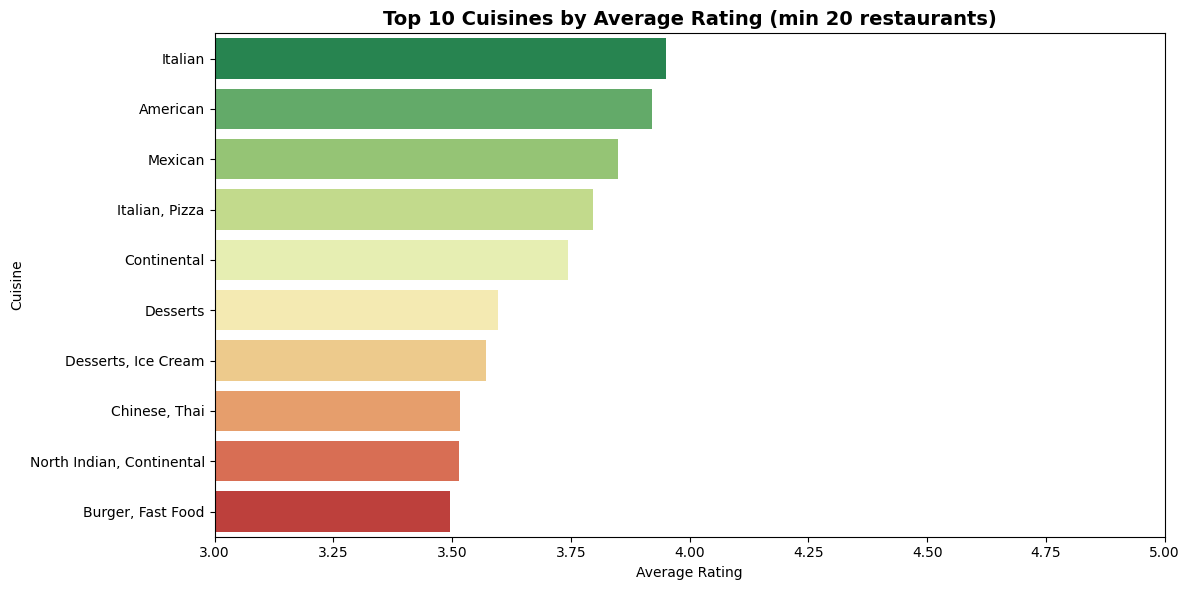

In [355]:
# Top 10 Cuisines by Average Rating
cuisine_rating = (df[df['Aggregate rating'] > 0]
    .groupby('Cuisines')['Aggregate rating']
    .agg(['mean', 'count'])
    .query('count >= 20')
    .sort_values('mean', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=cuisine_rating['mean'], y=cuisine_rating.index, palette='RdYlGn_r')
plt.title('Top 10 Cuisines by Average Rating (min 20 restaurants)', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.xlim(3, 5)
plt.tight_layout()
plt.show()

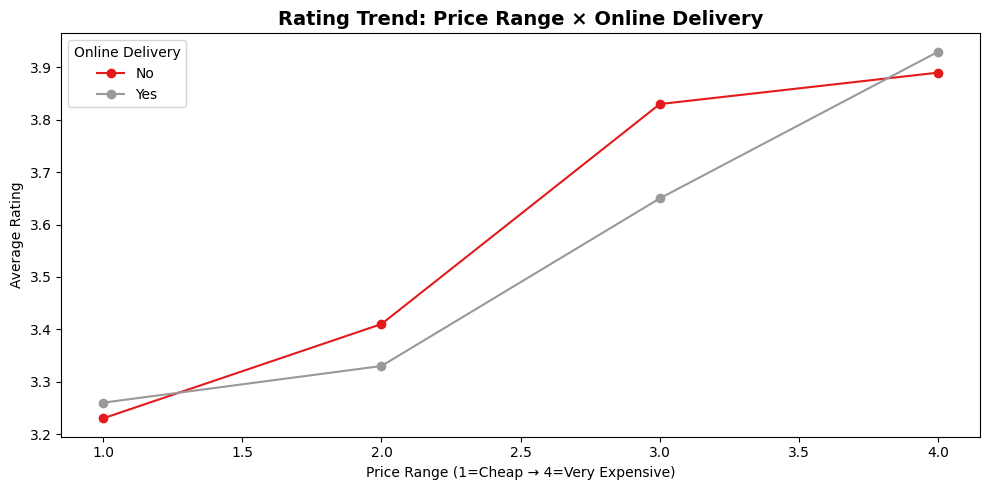

In [356]:
# Trend — Average Rating by Price Range (cluster comparison)
city_price_rating = (df[df['Aggregate rating'] > 0]
    .groupby(['Price range', 'Has Online delivery'])['Aggregate rating']
    .mean()
    .unstack() # Convert to table format
    .round(2)
)

city_price_rating.plot(kind='line', marker='o', figsize=(10, 5), colormap='Set1')
plt.title('Rating Trend: Price Range × Online Delivery', fontsize=14, fontweight='bold')
plt.xlabel('Price Range (1=Cheap → 4=Very Expensive)')
plt.ylabel('Average Rating')
plt.legend(title='Online Delivery')
plt.tight_layout()
plt.show()

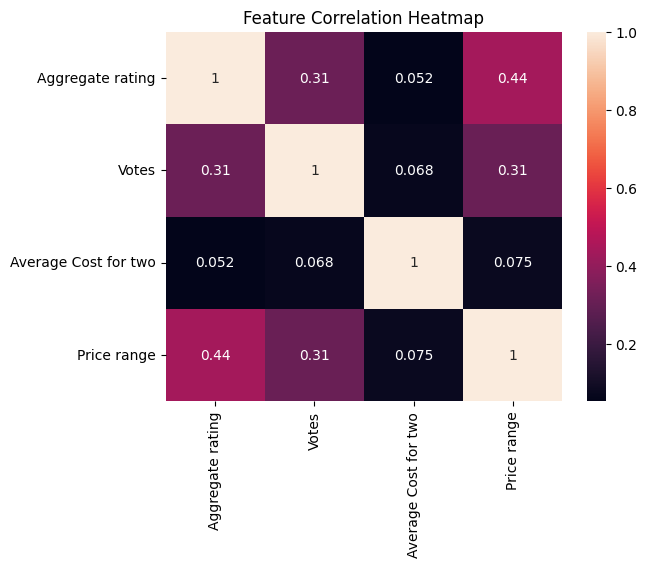

In [357]:
# Correlation Heatmap

# Select numerical columns
columns = [
    "Aggregate rating",
    "Votes",
    "Average Cost for two",
    "Price range"
]

# Calculate correlation
correlation = df[columns].corr()

# Create heatmap
sns.heatmap(
    correlation,
    annot=True
)

plt.title("Feature Correlation Heatmap")

plt.show()

---
## Phase 9 — Drawing Insights & Business Conclusions

**Business Scenario:** EDA is valuable only when it leads to actionable, data-driven recommendations.

Let's convert all our observations into real business insights.

In [358]:
# KPI Summary

# Total number of restaurants
total_restaurants = len(df)

# Average rating
rated = df[df["Aggregate rating"] > 0]

average_rating = rated["Aggregate rating"].mean()

# Percentage of restaurants with online delivery
online_delivery = (
    df["Has Online delivery"] == "Yes"
).mean() * 100

# Percentage of restaurants with table booking
table_booking = (
    df["Has Table booking"] == "Yes"
).mean() * 100

# Find the city with the most restaurants
city_counts = df["City"].value_counts()

top_city = city_counts.index[0]
top_city_count = city_counts.iloc[0]

# Display the results
print("KPI Summary")
print("-" * 30)

print("Total Restaurants:", total_restaurants)
print("Average Rating:", round(average_rating, 2))
print("Online Delivery:", round(online_delivery, 1), "%")
print("Table Booking:", round(table_booking, 1), "%")
print("Top City:", top_city)
print("Restaurants in Top City:", top_city_count)

KPI Summary
------------------------------
Total Restaurants: 9551
Average Rating: 3.44
Online Delivery: 25.7 %
Table Booking: 12.1 %
Top City: New Delhi
Restaurants in Top City: 5473


## 1. Rating Category Distribution

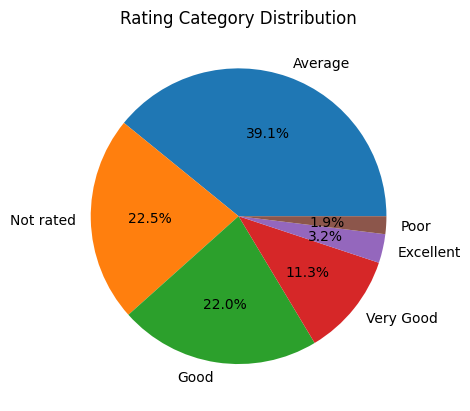

In [359]:
# Rating Category Distribution

rating_counts = df["Rating text"].value_counts()

rating_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Rating Category Distribution")
plt.ylabel("")

plt.show()

## 2. Average Rating by Price Range

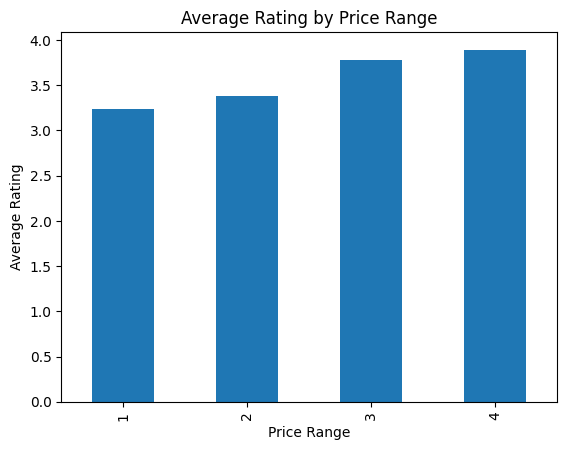

In [360]:
# Average Rating by Price Range

rated = df[df["Aggregate rating"] > 0]

average_rating = rated.groupby(
    "Price range"
)["Aggregate rating"].mean()

average_rating.plot(kind="bar")

plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")

plt.show()

## 3. Top 5 Cities by Restaurant Count

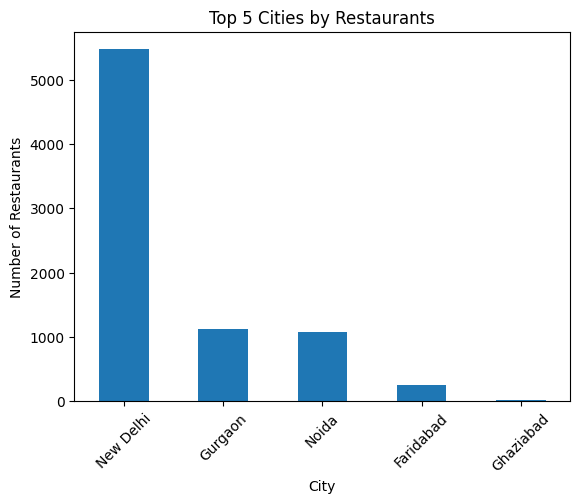

In [361]:
# Top 5 Cities

top_cities = df["City"].value_counts().head(5)

top_cities.plot(kind="bar")

plt.title("Top 5 Cities by Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

## 📋 Final Recommendations — Zomato EDA

### 1. Fix the Ratings Gap
**22.49%** of restaurants are "Not Rated." Zomato should send push notifications or offer incentives to encourage customers to leave ratings — this would improve both visibility and trust.

### 2. Promote Online Delivery
Only **25.66%** of restaurants offer online delivery, but their average rating (**3.25**) is noticeably better than restaurants without delivery (**2.47**). Onboarding non-delivery restaurants represents a high-impact opportunity for Zomato.

### 3. Table Booking Feature Is Underused
Only **12.12%** of restaurants offer table booking, and those that do have a better average rating (**3.44** vs **2.56** without booking). Zomato should promote this feature more widely, especially in the fine-dining segment.

### 4. Premium Restaurants Perform Better
Price range 4 (most expensive) has an average rating of **3.89**, compared to just **3.24** for price range 1 (cheapest). However, the correlation between cost and rating is weak (**0.08**) — meaning **being expensive alone doesn't guarantee a good rating**; quality and service matter more.

### 5. Votes Are a Trust Signal
The correlation between votes and rating is **0.41** — the more engagement a restaurant gets, the more stable/higher its rating tends to be. New restaurants should focus on collecting early reviews.

### 6. Winning Cuisines
**Italian (3.95)**, **American (3.92)**, and **Mexican (3.85)** are the top-rated cuisines (among those with at least 20 restaurants). Meanwhile, North Indian is the most common cuisine (936 restaurants) but its average rating isn't as high — a sign of **market saturation**, meaning differentiation is key.

### 7. Market Concentration Risk
Just 3 cities — **New Delhi, Gurgaon, and Noida** — account for over **77%** of all restaurants. Expansion strategy should focus on tier-2 cities where competition is lower.

### 8. Data Quality Note
The currency data shows this is a **multi-country dataset** (beyond India — includes US, UK, UAE, Brazil, etc.). If the analysis should be India-specific, filtering by `Currency = "Indian Rupees(Rs.)"` would ensure cost/rating comparisons are apples-to-apples.

---
## Phase 10 — Complete End-to-End EDA Summary

### What We Did — Full EDA Workflow Recap

| Phase | Task | Finding |
|-------|------|---------|
| 1 | Understood EDA objectives | Defined key business questions |
| 2 | Dataset inspection | 9,551 rows × 21 columns, mixed types |
| 3 | Data quality | 9 missing Cuisines, 0 duplicates |
| 4 | Univariate analysis | 22% Not Rated, 46% restaurants are cheap |
| 5 | Bivariate analysis | Price & Table booking correlate with rating |
| 6 | Multivariate analysis | New Delhi dominates across all metrics |
| 7 | Outlier analysis | Extreme votes are real signals (not errors) |
| 8 | Pattern discovery | Higher cost → better rating (linear trend) |
| 9 | Business conclusions | 4 actionable recommendations derived |
| 10 | Dataset ready | Clean data ready for ML or dashboard |

In [362]:
# Create a copy of the dataset
df_clean = df.copy()

In [371]:
# Convert Yes/No into 1/0
df_clean["Has Online delivery"] = df_clean[
    "Has Online delivery"
].replace({
    "Yes": 1,
    "No": 0
})
df_clean["Has Online delivery"]

,Has Online delivery
0,0
1,0
2,0
3,0
4,0
...,...
9546,0
9547,0
9548,0
9549,0


In [370]:
df_clean["Has Table booking"] = df_clean[
    "Has Table booking"
].replace({
    "Yes": 1,
    "No": 0
})
df_clean["Has Table booking"]

,Has Table booking
0,1
1,1
2,1
3,0
4,1
...,...
9546,0
9547,0
9548,0
9549,0


In [373]:
df_clean["Is delivering now"] = df_clean[
    "Is delivering now"
].replace({
    "Yes": 1,
    "No": 0
})
df_clean["Is delivering now"]

,Is delivering now
0,0
1,0
2,0
3,0
4,0
...,...
9546,0
9547,0
9548,0
9549,0


In [375]:
# Create Is Rated column

df_clean["Is Rated"] = 0

df_clean.loc[
    df_clean["Aggregate rating"] > 0,
    "Is Rated"
] = 1
df_clean["Is Rated"]


,Is Rated
0,1
1,1
2,1
3,1
4,1
...,...
9546,1
9547,1
9548,1
9549,1


In [367]:

# Display dataset information

print("Final Dataset Shape:")
print(df_clean.shape)

print()

print("First 5 Rows:")
print(
    df_clean[
        [
            "Restaurant Name",
            "City",
            "Aggregate rating",
            "Votes",
            "Has Online delivery",
            "Has Table booking",
            "Is Rated"
        ]
    ].head()
)

Final Dataset Shape:
(9551, 22)

First 5 Rows:
          Restaurant Name              City  Aggregate rating  Votes  \
0        Le Petit Souffle       Makati City               4.8    314   
1        Izakaya Kikufuji       Makati City               4.5    591   
2  Heat - Edsa Shangri-La  Mandaluyong City               4.4    270   
3                    Ooma  Mandaluyong City               4.9    365   
4             Sambo Kojin  Mandaluyong City               4.8    229   

   Has Online delivery  Has Table booking  Is Rated  
0                    0                  1         1  
1                    0                  1         1  
2                    0                  1         1  
3                    0                  0         1  
4                    0                  1         1  


In [368]:
# Save the clean dataset

df_clean.to_csv(
    "zomato_clean.csv",
    index=False
)

print("Clean dataset saved successfully!")
print("Dataset is ready for Power BI or Machine Learning.")

Clean dataset saved successfully!
Dataset is ready for Power BI or Machine Learning.


---
## Practice Questions for you guys

Test your understanding with these exercises:

**Basic:**
1. How many restaurants have a rating above 4.0?
2. What is the most common cuisine type in the dataset?
3. Which city has the highest average aggregate rating?

**Intermediate:**
4. Find the top 5 restaurants with the most votes in New Delhi.
5. Calculate the percentage of restaurants in each 'Rating text' category.
6. What is the average cost for two in Price Range 4 restaurants?

**Advanced:**
7. Create a bar chart comparing average rating across all cities with at least 50 restaurants.
8. Use IQR method to detect and report outliers in 'Average Cost for two'.
9. Build a pivot table showing average votes per city × price range combination.
10. Write a Python function that takes a city name and returns a complete EDA summary for that city.

---
*End of Phase Zomato Restaurant Analysis*  
